In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#2e3148',
    'axes.labelcolor'  : '#c9d1d9',
    'text.color'       : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'grid.color'       : '#21262d',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlecolor'  : '#e6edf3',
    'axes.titlepad'    : 12,
})

PALETTE = ["#5caf91", "#448d72", "#40866c", "#34705a", "#2d755b", "#1c4838"]

RAW_DIR  = '../data/raw'
PROC_DIR = '../data/processed'
VIZ_DIR  = '../visuals'

os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(VIZ_DIR,  exist_ok=True)

print('Libraries loaded. Output directories ready.')

Libraries loaded. Output directories ready.


In [ ]:
accounts = pd.read_csv(
    f'{RAW_DIR}/accounts.csv',
    parse_dates=['signup_date']
)

subscriptions = pd.read_csv(
    f'{RAW_DIR}/subscriptions.csv',
    parse_dates=['start_date', 'end_date']
)

feature_usage = pd.read_csv(
    f'{RAW_DIR}/feature_usage.csv',
    parse_dates=['usage_date']
)

support_tickets = pd.read_csv(
    f'{RAW_DIR}/support_tickets.csv',
    parse_dates=['submitted_at', 'closed_at']
)

churn_events = pd.read_csv(
    f'{RAW_DIR}/churn_events.csv',
    parse_dates=['churn_date']
)

datasets = {
    'accounts'       : accounts,
    'subscriptions'  : subscriptions,
    'feature_usage'  : feature_usage,
    'support_tickets': support_tickets,
    'churn_events'   : churn_events,
}

print('Datasets loaded:')
for name, df in datasets.items():
    print(f'  {name:<20} {df.shape[0]:>6,} rows × {df.shape[1]:>2} cols')

Datasets loaded:
  accounts                500 rows × 10 cols
  subscriptions         5,000 rows × 14 cols
  feature_usage        25,000 rows ×  8 cols
  support_tickets       2,000 rows ×  9 cols
  churn_events            600 rows ×  9 cols


## 2. Data Quality Checks

In [ ]:
for name, df in datasets.items():
    print("\n" + "=" * 55)
    print(f"{name.upper()}")
    print("=" * 55)
    print(df.dtypes.to_string())


ACCOUNTS
account_id                 object
account_name               object
industry                   object
country                    object
signup_date        datetime64[ns]
referral_source            object
plan_tier                  object
seats                       int64
is_trial                     bool
churn_flag                   bool

SUBSCRIPTIONS
subscription_id              object
account_id                   object
start_date           datetime64[ns]
end_date             datetime64[ns]
plan_tier                    object
seats                         int64
mrr_amount                    int64
arr_amount                    int64
is_trial                       bool
upgrade_flag                   bool
downgrade_flag                 bool
churn_flag                     bool
billing_frequency            object
auto_renew_flag                bool

FEATURE_USAGE
usage_id                       object
subscription_id                object
usage_date             datetime64[ns]
fe

In [ ]:
def null_report(df, name):
    """Returns a DataFrame showing null counts and percentages per column."""
    nulls = df.isnull().sum()
    pct   = (nulls / len(df) * 100).round(2)
    report = pd.DataFrame({'null_count': nulls, 'null_pct': pct})
    report = report[report['null_count'] > 0].sort_values('null_pct', ascending=False)
    print(f'\n── {name} ── ({len(df):,} rows)')
    if report.empty:
        print('  ✓ No nulls found')
    else:
        print(report.to_string())
    return report

null_reports = {name: null_report(df, name) for name, df in datasets.items()}


── accounts ── (500 rows)
  ✓ No nulls found

── subscriptions ── (5,000 rows)
          null_count  null_pct
end_date        4514     90.28

── feature_usage ── (25,000 rows)
  ✓ No nulls found

── support_tickets ── (2,000 rows)
                    null_count  null_pct
satisfaction_score         825     41.25

── churn_events ── (600 rows)
               null_count  null_pct
feedback_text         148     24.67


In [ ]:
pk_map = {
    'accounts'       : 'account_id',
    'subscriptions'  : 'subscription_id',
    'feature_usage'  : 'usage_id',
    'support_tickets': 'ticket_id',
    'churn_events'   : 'churn_event_id',
}

for name, pk in pk_map.items():
    df   = datasets[name]
    dups = df[pk].duplicated().sum()
    status = '✓ No duplicates' if dups == 0 else f'⚠ {dups} duplicates'
    print(f'{name:<20} PK={pk:<25} {status}')

accounts             PK=account_id                ✓ No duplicates
subscriptions        PK=subscription_id           ✓ No duplicates
feature_usage        PK=usage_id                  ⚠ 21 duplicates
support_tickets      PK=ticket_id                 ✓ No duplicates
churn_events         PK=churn_event_id            ✓ No duplicates


In [ ]:
def orphan_check(child_df, child_fk, parent_df, parent_pk, child_name):
    """Identify rows in child table with no matching parent key."""
    orphans = child_df[~child_df[child_fk].isin(parent_df[parent_pk])]
    print(f'{child_name}: {len(orphans)} orphan rows')
    return orphans

orphan_check(subscriptions,   'account_id',      accounts,      'account_id',      'subscriptions   → accounts')
orphan_check(feature_usage,   'subscription_id', subscriptions, 'subscription_id', 'feature_usage   → subscriptions')
orphan_check(support_tickets, 'account_id',      accounts,      'account_id',      'support_tickets → accounts')
orphan_check(churn_events,    'account_id',      accounts,      'account_id',      'churn_events    → accounts')

merged_dates = subscriptions.merge(accounts[['account_id','signup_date']], on='account_id')
invalid_dates = merged_dates[merged_dates['start_date'] < merged_dates['signup_date']]
print(f'Subscriptions starting before signup: {len(invalid_dates)}')

subscriptions   → accounts: 0 orphan rows
feature_usage   → subscriptions: 0 orphan rows
support_tickets → accounts: 0 orphan rows
churn_events    → accounts: 0 orphan rows
Subscriptions starting before signup: 0


In [ ]:
print('=== SUBSCRIPTIONS — MRR / ARR / Seats ===')
display(subscriptions[['mrr_amount','arr_amount','seats']]
        .describe(percentiles=[.25,.50,.75,.90]).round(2))

print('\n=== SUPPORT TICKETS — Resolution & CSAT ===')
display(support_tickets[['resolution_time_hours','first_response_time_minutes','satisfaction_score']]
        .describe(percentiles=[.25,.50,.75,.90]).round(2))

print('\n=== CHURN EVENTS — Refunds ===')
display(churn_events[['refund_amount_usd']].describe().round(2))

=== SUBSCRIPTIONS — MRR / ARR / Seats ===


,mrr_amount,arr_amount,seats
count,5000.00,5000.00,5000.00
mean,2267.75,27212.99,29.85
std,3421.38,41056.50,23.09
min,0.00,0.00,1.00
25%,285.00,3420.00,14.00
50%,931.00,11172.00,24.00
75%,2786.00,33432.00,40.00
90%,6169.00,74028.00,60.00
max,33830.00,405960.00,189.00



=== SUPPORT TICKETS — Resolution & CSAT ===


,resolution_time_hours,first_response_time_minutes,satisfaction_score
count,2000.00,2000.00,1175.00
mean,35.86,88.48,3.98
std,21.14,51.53,0.81
min,1.00,1.00,3.00
25%,17.00,43.00,3.00
50%,35.00,88.00,4.00
75%,54.00,131.00,5.00
90%,65.00,160.10,5.00
max,72.00,180.00,5.00



=== CHURN EVENTS — Refunds ===


,refund_amount_usd
count,600.00
mean,14.42
std,39.22
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,392.92


In [ ]:
cats = [
    (accounts,     'plan_tier',         'Plan Tier Distribution'),
    (accounts,     'industry',          'Industry Distribution'),
    (accounts,     'referral_source',   'Referral Source'),
    (accounts,     'country',           'Country (Top 10)'),
    (churn_events, 'reason_code',       'Churn Reason Codes'),
    (support_tickets, 'priority',       'Ticket Priority'),
]

for df, col, label in cats:
    vc = df[col].value_counts().head(10)
    print(f'\n── {label} ──')
    print(vc.to_string())


── Plan Tier Distribution ──
plan_tier
Pro           178
Basic         168
Enterprise    154

── Industry Distribution ──
industry
DevTools         113
FinTech          112
Cybersecurity    100
HealthTech        96
EdTech            79

── Referral Source ──
referral_source
organic    114
other      103
ads         98
event       96
partner     89

── Country (Top 10) ──
country
US    291
UK     58
IN     49
AU     32
DE     25
CA     23
FR     22

── Churn Reason Codes ──
reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91

── Ticket Priority ──
priority
urgent    514
high      510
medium    491
low       485


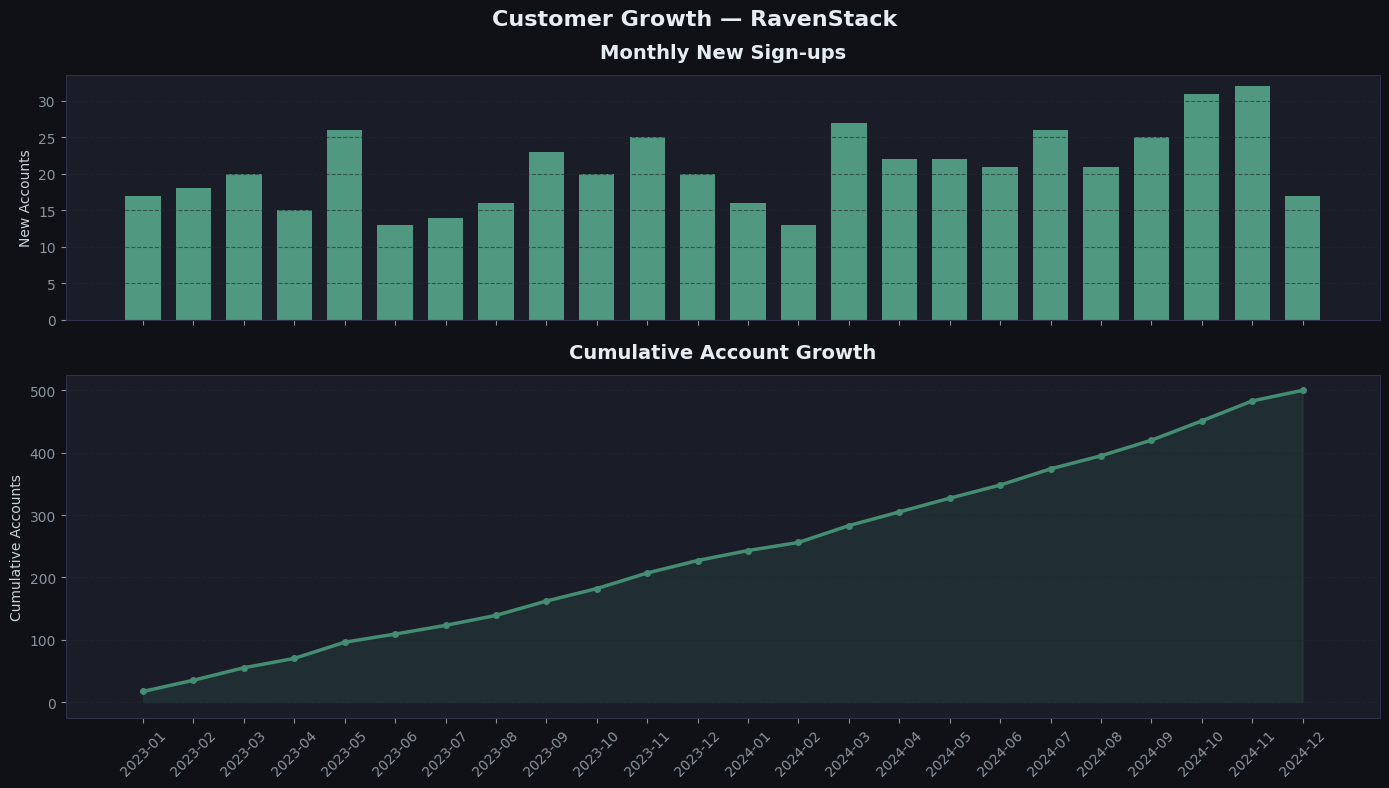

Saved: 01_customer_growth.png


In [ ]:

monthly_signups = (
    accounts
    .assign(month=accounts['signup_date'].dt.to_period('M'))
    .groupby('month')['account_id']
    .count()
    .reset_index()
)
monthly_signups['month_str'] = monthly_signups['month'].astype(str)
monthly_signups['cumulative'] = monthly_signups['account_id'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                 gridspec_kw={'height_ratios': [1, 1.4]})
fig.suptitle('Customer Growth — RavenStack', fontsize=16, fontweight='bold', color='#e6edf3', y=0.98)

ax1.bar(monthly_signups['month_str'], monthly_signups['account_id'],
        color=PALETTE[0], alpha=0.85, width=0.7)
ax1.set_ylabel('New Accounts')
ax1.set_title('Monthly New Sign-ups')
ax1.grid(axis='y')

ax2.plot(monthly_signups['month_str'], monthly_signups['cumulative'],
         color=PALETTE[1], linewidth=2.5, marker='o', markersize=4)
ax2.fill_between(monthly_signups['month_str'], monthly_signups['cumulative'],
                  alpha=0.15, color=PALETTE[1])
ax2.set_ylabel('Cumulative Accounts')
ax2.set_title('Cumulative Account Growth')
ax2.grid(axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/01_customer_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_customer_growth.png')

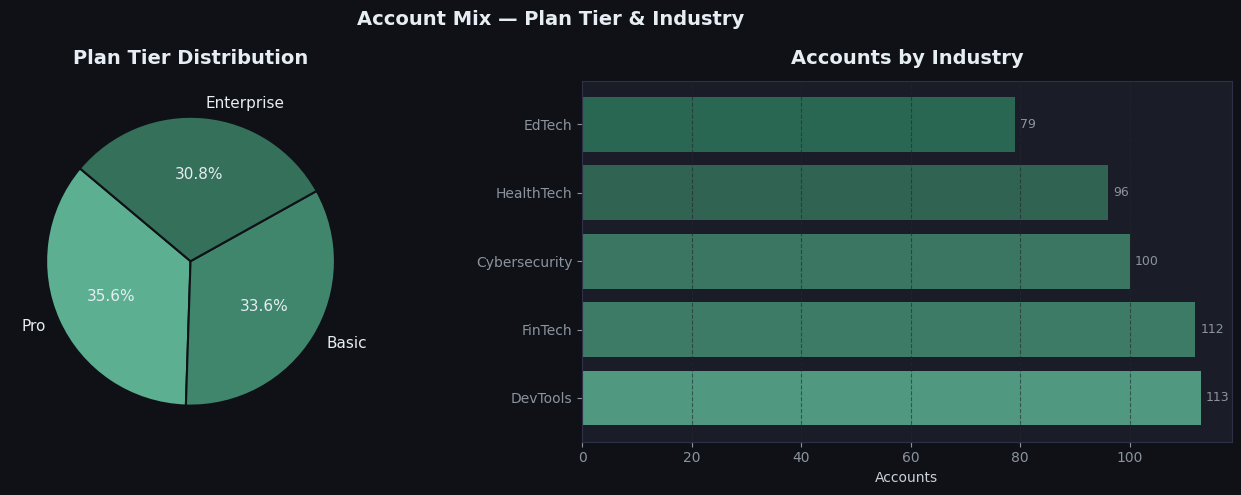

Saved: 02_plan_industry_mix.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Account Mix — Plan Tier & Industry', fontsize=14, fontweight='bold',
             color='#e6edf3')

plan_counts = accounts['plan_tier'].value_counts()
wedge_colors = [PALETTE[0], PALETTE[2], PALETTE[3]]
axes[0].pie(plan_counts, labels=plan_counts.index, autopct='%1.1f%%',
            colors=wedge_colors, startangle=140,
            textprops={'color': '#e6edf3', 'fontsize': 11},
            wedgeprops={'edgecolor': '#0f1117', 'linewidth': 1.5})
axes[0].set_title('Plan Tier Distribution', color='#e6edf3')
axes[0].set_facecolor('#1a1d27')

industry_counts = accounts['industry'].value_counts()
bars = axes[1].barh(industry_counts.index, industry_counts.values,
                     color=PALETTE[:len(industry_counts)], alpha=0.85)
axes[1].set_xlabel('Accounts')
axes[1].set_title('Accounts by Industry', color='#e6edf3')
axes[1].grid(axis='x')
for bar, val in zip(bars, industry_counts.values):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9, color='#8b949e')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/02_plan_industry_mix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_plan_industry_mix.png')

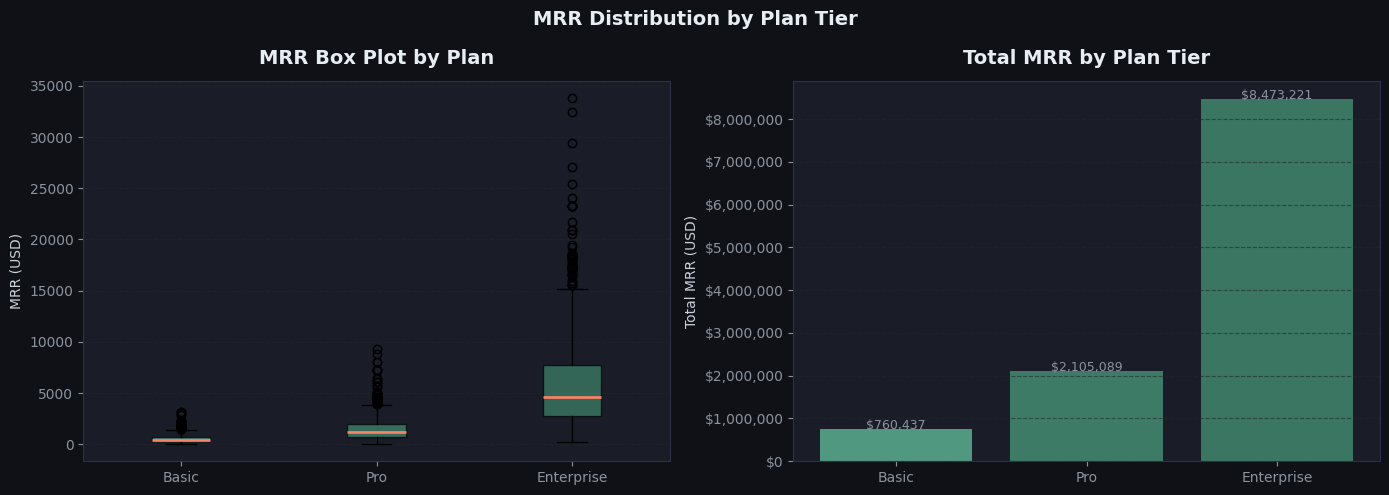

Saved: 03_mrr_by_plan.png


In [ ]:
paid_subs = subscriptions[(subscriptions['is_trial'] == False) &
                           (subscriptions['mrr_amount'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MRR Distribution by Plan Tier', fontsize=14,
             fontweight='bold', color='#e6edf3')

plan_order = ['Basic', 'Pro', 'Enterprise']
plan_data  = [paid_subs[paid_subs['plan_tier'] == p]['mrr_amount'].dropna()
               for p in plan_order]

bp = axes[0].boxplot(plan_data, labels=plan_order, patch_artist=True,
                      medianprops={'color': '#f78166', 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('MRR (USD)')
axes[0].set_title('MRR Box Plot by Plan')
axes[0].grid(axis='y')

mrr_by_plan = paid_subs.groupby('plan_tier')['mrr_amount'].sum().reindex(plan_order)
axes[1].bar(mrr_by_plan.index, mrr_by_plan.values,
             color=PALETTE[:3], alpha=0.85)
axes[1].set_ylabel('Total MRR (USD)')
axes[1].set_title('Total MRR by Plan Tier')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
axes[1].grid(axis='y')
for i, v in enumerate(mrr_by_plan.values):
    axes[1].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9, color='#8b949e')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/03_mrr_by_plan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_mrr_by_plan.png')

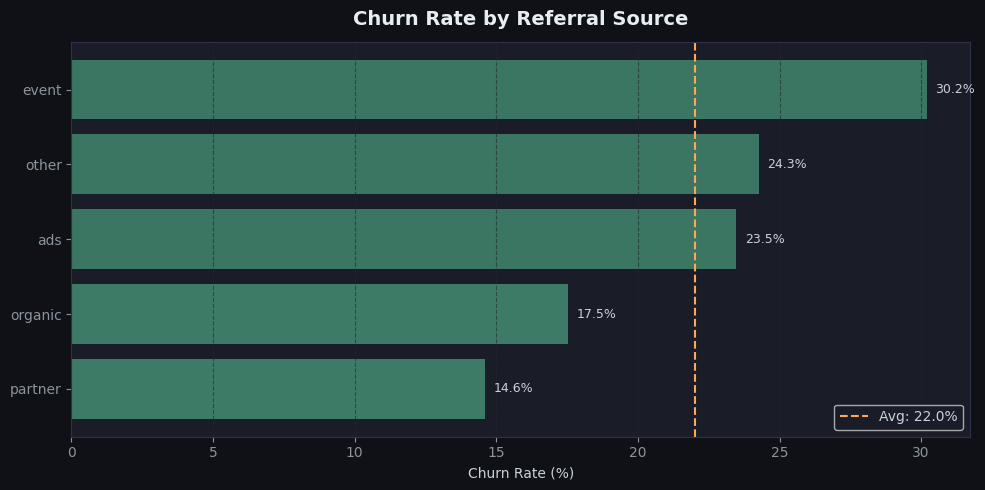

Saved: 04_churn_by_referral.png


In [ ]:
ref_churn = (
    accounts
    .groupby('referral_source')
    .agg(total=('account_id', 'count'),
         churned=('churn_flag', 'sum'))
    .assign(churn_rate=lambda x: x['churned'] / x['total'] * 100)
    .sort_values('churn_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[2] if v > ref_churn['churn_rate'].mean() else PALETTE[1]
          for v in ref_churn['churn_rate']]
bars = ax.barh(ref_churn.index, ref_churn['churn_rate'], color=colors, alpha=0.85)
ax.axvline(ref_churn['churn_rate'].mean(), color='#ffa657',
            linestyle='--', linewidth=1.5, label=f'Avg: {ref_churn["churn_rate"].mean():.1f}%')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Referral Source', fontsize=14, fontweight='bold', color='#e6edf3')
ax.legend()
ax.grid(axis='x')
for bar, val in zip(bars, ref_churn['churn_rate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/04_churn_by_referral.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_churn_by_referral.png')

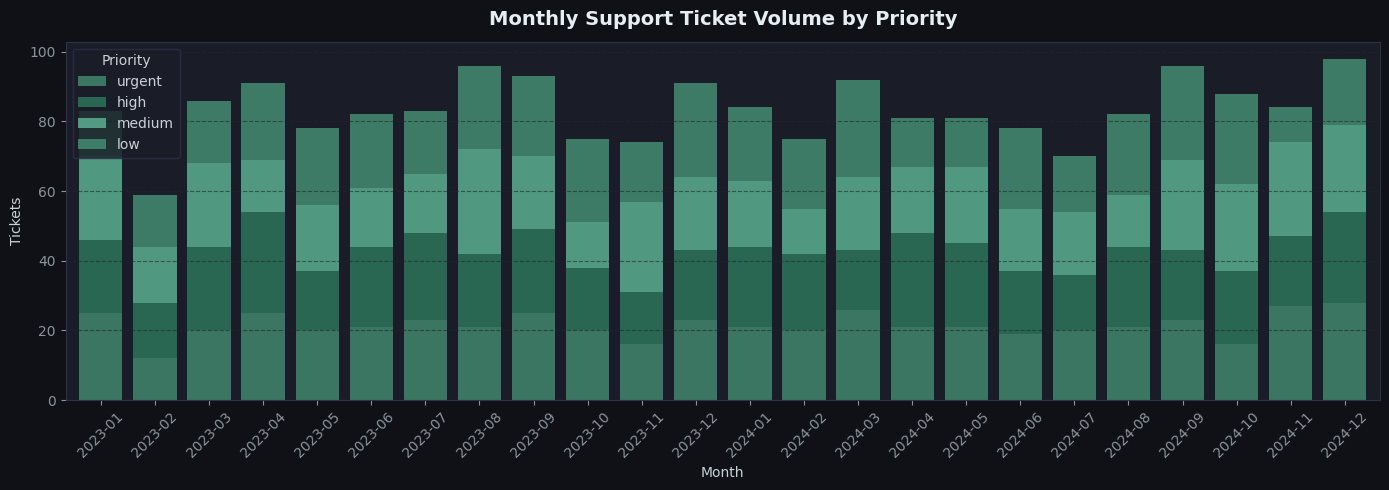

Saved: 05_ticket_volume.png


In [ ]:
priority_order  = ['urgent', 'high', 'medium', 'low']
priority_colors = [PALETTE[2], PALETTE[4], PALETTE[0], PALETTE[1]]

monthly_tickets = (
    support_tickets
    .assign(month=support_tickets['submitted_at'].dt.to_period('M').astype(str))
    .groupby(['month', 'priority'])['ticket_id']
    .count()
    .unstack('priority')
    .fillna(0)
    [priority_order]
)

fig, ax = plt.subplots(figsize=(14, 5))
monthly_tickets.plot(kind='bar', stacked=True, ax=ax,
                      color=priority_colors, alpha=0.85, width=0.8)
ax.set_title('Monthly Support Ticket Volume by Priority',
              fontsize=14, fontweight='bold', color='#e6edf3')
ax.set_xlabel('Month')
ax.set_ylabel('Tickets')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y')
ax.legend(title='Priority', loc='upper left',
           facecolor='#1a1d27', edgecolor='#2e3148', labelcolor='#c9d1d9')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/05_ticket_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_ticket_volume.png')

## 5. Save Processed Data

In [ ]:
accounts_clean = accounts.copy()

subscriptions_clean = subscriptions.copy()
subscriptions_clean['is_active'] = subscriptions_clean['end_date'].isna() & \
                                    (subscriptions_clean['churn_flag'] == False)

support_clean = support_tickets.copy()
mask = support_clean['resolution_time_hours'].isna() & \
       support_clean['closed_at'].notna() & \
       support_clean['submitted_at'].notna()
support_clean.loc[mask, 'resolution_time_hours'] = (
    (support_clean.loc[mask, 'closed_at'] - support_clean.loc[mask, 'submitted_at'])
    .dt.total_seconds() / 3600
).round(2)

accounts_clean.to_csv(f'{PROC_DIR}/accounts_clean.csv', index=False)
subscriptions_clean.to_csv(f'{PROC_DIR}/subscriptions_clean.csv', index=False)
feature_usage.to_csv(f'{PROC_DIR}/feature_usage_clean.csv', index=False)
support_clean.to_csv(f'{PROC_DIR}/support_tickets_clean.csv', index=False)
churn_events.to_csv(f'{PROC_DIR}/churn_events_clean.csv', index=False)

print('✓ All processed files saved to data/processed/')


print('\n=== KEY METRICS SNAPSHOT ===')
total_accounts  = len(accounts)
churn_rate      = accounts['churn_flag'].mean() * 100
trial_rate      = accounts['is_trial'].mean() * 100
total_mrr       = paid_subs['mrr_amount'].sum()
total_arr       = paid_subs['arr_amount'].sum()
avg_csat        = support_tickets['satisfaction_score'].mean()

print(f'  Total Accounts    : {total_accounts:,}')
print(f'  Churn Rate        : {churn_rate:.1f}%')
print(f'  Trial Rate        : {trial_rate:.1f}%')
print(f'  Total MRR (hist.) : ${total_mrr:,.2f}')
print(f'  Total ARR (hist.) : ${total_arr:,.2f}')
print(f'  Avg CSAT Score    : {avg_csat:.2f} / 5')

✓ All processed files saved to data/processed/

=== KEY METRICS SNAPSHOT ===
  Total Accounts    : 500
  Churn Rate        : 22.0%
  Trial Rate        : 19.4%
  Total MRR (hist.) : $11,338,747.00
  Total ARR (hist.) : $136,064,964.00
  Avg CSAT Score    : 3.98 / 5
